#Problem Definition
AllLife Bank aims to improve the penetration of its credit card services by gaining a better understanding of its existing customers and their behavioral patterns. The bank has identified opportunities to increase customer acquisition through personalized marketing campaigns and upselling strategies. In addition, customer feedback indicates dissatisfaction with support services, leading the bank to focus on improving service delivery and response efficiency.

The objective of this project is to segment customers based on their spending behavior, credit usage patterns, and interactions with the bank using clustering techniques. Identifying distinct customer groups will help the bank develop targeted marketing strategies, improve customer relationship management, enhance service quality, and increase overall customer satisfaction and profitability.


#Import Libraries

In [1]:
#Data manipulation and analysis
import numpy as np
import pandas as pd

#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#To ignore warnings
import warnings
warnings.filterwarnings('ignore')

#Machine learning Libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

#Evaluation metrics
from sklearn.metrics import silhouette_score

#For hierarchical clustering visualization
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import cophenet

#Display settings
pd.set_option('display.max_columns', None)

#Setting plot style
sns.set(style = 'whitegrid')

Necessary libraries for data manipulation, visualization, preprocessing, clustering and evaluation have been successfully imported.
- Pandas and NumPy will be used for handling and analyzing the dataset efficiently.
- Matplotlib and Seaborn will help in creating visualizations to understand customer behavior and relationships among variables.
- Scikit-learn libraries will be used for data preprocessing, K-Means clustering, Hierarchical clustering, and cluster evaluation.
- Hierarchical clustering libraries from Scipy have been imported to generate dendrograms for identifying the optimal number of clusters.
- Warning messages have been suppressed and display settings have been adjusted for better readability and smoother analysis.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_excel('/content/drive/MyDrive/Credit Card Customer Data.xlsx')

Mounted at /content/drive


###Observation:
- The dataset has been successfully imported into the notebook using the **read_excel()** function.
- Google Drive has been mounted successfully, allowing access to the dataset stored in Drive.
- The previous error was resolved by using the appropriate function for reading Excel files.
- The dataset is now ready for further exploration and preprocessing steps.

#Exploratory Data Analysis
##Checking the Structure of Data

In [3]:
print(df.head())

   Sl_No  Customer Key  Avg_Credit_Limit  Total_Credit_Cards  \
0      1         87073            100000                   2   
1      2         38414             50000                   3   
2      3         17341             50000                   7   
3      4         40496             30000                   5   
4      5         47437            100000                   6   

   Total_visits_bank  Total_visits_online  Total_calls_made  
0                  1                    1                 0  
1                  0                   10                 9  
2                  1                    3                 4  
3                  1                    1                 4  
4                  0                   12                 3  


###Observation
- The first five records of the dataset have been displayed successfully.
- The dataset contains customer-specific information related to credit card usage and customer interaction with the blank.
- Variables such as average credit limit, total credit cards, blank visits, online visits, and calls made indicate that the dataset captures both financial behavior and customer engagement patterns.
- **Sl_No** appears to represent the serial number of customers, while **Customer Key** acts as a unique customer identifier.
- Initial observation suggests significant variation in customer behavior, which indicates the possibility of distinct customer segments within the dataset.

In [4]:
print(df.tail())

     Sl_No  Customer Key  Avg_Credit_Limit  Total_Credit_Cards  \
655    656         51108             99000                  10   
656    657         60732             84000                  10   
657    658         53834            145000                   8   
658    659         80655            172000                  10   
659    660         80150            167000                   9   

     Total_visits_bank  Total_visits_online  Total_calls_made  
655                  1                   10                 0  
656                  1                   13                 2  
657                  1                    9                 1  
658                  1                   15                 0  
659                  0                   12                 2  


###Observation
- The last five records of the dataset have been displayed successfully, confirming that the dataset has been loaded completely without truncation.
- The dataset contains 660 customer records with variables related to credit card usage and customer interaction channels.
- Customers in the final records show relatively high average credit limits and a higher number of credit cards, indicating the presence of potentially high-value customers.
- Online visits appear to be comparatively high for some customers, while calls made to the bank are relatively low, suggesting varying customer engagement preferences.
- The variation observed across customer records further supports the need for customer segmentation using clustering techniques.

In [5]:
print(df.shape)

(660, 7)


###Observation
- The dataset contains 660 rows and 7 columns.
- Each row represents an individual customer of AllLife Bank.
- The 7 columns consist of variables related to customer identification, credit card usage, spending capacity, and customer interaction behavior.
- The dataset size is sufficient for performing exploratory data analysis and clustering-based customer segmentation.

In [6]:
print(df.columns)

Index(['Sl_No', 'Customer Key', 'Avg_Credit_Limit', 'Total_Credit_Cards',
       'Total_visits_bank', 'Total_visits_online', 'Total_calls_made'],
      dtype='object')


###Observation
- The dataset contains multiple columns representing customer-related behavioral information.
- Variables such as **Avg_Credit_Limit**, **Total_Credit_Cards**, **Tota_visits_bank**, **Total_visits_online**, and **Total_calls_made** are important for analyzing customer spending behavior and interaction patterns.
- **Sl_No** appears to be a serial number column, while **Customer Key** acts as a unique identifier for customers.
- The dataset mainly consists of numerical variables, which are suitable for clustering techniques such as K-Means and Hierarchical Clustering.
- These variables are expected to play a significantly role in identifying distinct customer segments based on financial behavior and customer engagement.

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB
None


###Observation
- The dataset contains 660 entries and 7 columns.
- All columns have 660 non-NULL values, indicating that there are no missing values present in the dataset.
- Every variable in the dataset is of integer (**int64**) data type, which makes the dataset suitable for numerical analysis and clustering algoeithms.
- The dataset occupies approximately 36.2 KB of memory, indicating that it is relatively lighweight and computationally efficient to process.
- Variables in the dataset represent customer identification details, credit card information, and customer interaction behavior with the bank.
- Since clustering algorithms work effectively with numerical data, the dataset is well-structured for performing customer segmentation analysis.

In [8]:
print(df.isnull().sum())

Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64


###Observation:
- No missing values are present in the dataset, as all columns contain zero NULL values.
- The dataset is complete and does not require any missing value treatment or imputation.
- Since there are no NULL values, the quality and consistency of the dataset are suitable for futher exploratory data analysis and clustering techniques.
- The absence of missing data will help improve the reliability and accuracy of the clustering results.

##Checking the Types of Data

In [9]:
print(df.dtypes)

Sl_No                  int64
Customer Key           int64
Avg_Credit_Limit       int64
Total_Credit_Cards     int64
Total_visits_bank      int64
Total_visits_online    int64
Total_calls_made       int64
dtype: object


###Observation:
- All variables in the dataset are of integer (**int64**) data type.
- The dataset contains only numerical variables, which makes it highly suitable for clustering algorithms such as K-Means and Hierarchical Clustering.
- No categorical variables are present in the dataset, eliminating the need for encoding or categorical data transformation.
- Since clustering techniques are distance-based methods, having numerical data simplifies preprocessing and model implementation.

##Checking Statistical Summary

In [10]:
print(df.describe())

            Sl_No  Customer Key  Avg_Credit_Limit  Total_Credit_Cards  \
count  660.000000    660.000000        660.000000          660.000000   
mean   330.500000  55141.443939      34574.242424            4.706061   
std    190.669872  25627.772200      37625.487804            2.167835   
min      1.000000  11265.000000       3000.000000            1.000000   
25%    165.750000  33825.250000      10000.000000            3.000000   
50%    330.500000  53874.500000      18000.000000            5.000000   
75%    495.250000  77202.500000      48000.000000            6.000000   
max    660.000000  99843.000000     200000.000000           10.000000   

       Total_visits_bank  Total_visits_online  Total_calls_made  
count         660.000000           660.000000        660.000000  
mean            2.403030             2.606061          3.583333  
std             1.631813             2.935724          2.865317  
min             0.000000             0.000000          0.000000  
25%         

###Observation:
- The dataset contains 660 customer records for all variables, confirming data consistency.
- The average credit limit of customers is approximately 34,574, while the maximum credit limit reaches 200,000, indicating the presence of high-value customers and possible outliers.
- Customers own an average of nearly 5 credit cards, with the number ranging from 1 to 10 cards.
- The average number of bank visits is around 2.4, whereas online visits average around 2.6, suggesting that customers use both physical and digital banking channels.
- The maximum number of online visits is significantly high at 15, indicating that some customers are highly digitally engaged.
- Customers make an average of approximately 3.6 calls to the bank, with some customers making up to 10 calls, which may indicate higher service dependency or customer issues.
- The large difference between minimum and maximum values in variables such as average credit limit and online vists suggests variability in customer behavior, supporting the need for customer segmentation through clustering techniques.

##Check for Data Irregularities

In [11]:
#Checking for duplicate records
print("Duplicate values:", df.duplicated().sum())

#Checking for negative values
print("\nNegative values in each column:")
print((df.select_dtypes(include = np.number) < 0).sum())

#Checking for zero credit limit customers
print("\nCustomers with Zero Credit Limit:",
      (df['Avg_Credit_Limit'] == 0).sum())

#Checking for customers with zero credit cards
print("Customers with Zero Credit Cards:",
      (df['Total_Credit_Cards'] == 0).sum())

#Checking for maximum values for unusual observations
print("\nMinimum Values:\n")
print(df.min())

Duplicate values: 0

Negative values in each column:
Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

Customers with Zero Credit Limit: 0
Customers with Zero Credit Cards: 0

Minimum Values:

Sl_No                      1
Customer Key           11265
Avg_Credit_Limit        3000
Total_Credit_Cards         1
Total_visits_bank          0
Total_visits_online        0
Total_calls_made           0
dtype: int64


###Observation:
- No duplicate values are present in the dataset, indicating that customer record is unique.
- No negative values are observed in any numerical column, confirming that the dataset is logically consistent and free from invalid numerical entries.
- No customers have zero credit limit or zero credit cards, which indicates that all customers in the dataset are active card credit card users.
- Minimum values across variables are logically valid, with customer interaction variables such as bank visits, online visits, and calls made starting from zero.
- Overall, the dataset does not show any major logical inconsistencies and is suitable for further exploratory data analysis and clustering modeling.

##Univariate Analysis

###Identifying Numerical & Categorical Variables

In [12]:
num_cols = df.select_dtypes(include = np.number).columns
cat_cols = df.select_dtypes(exclude = np.number).columns

print("Numerical Variables: \n")
print(num_cols)

print("\n Categorical Variables: \n")
print(cat_cols)

Numerical Variables: 

Index(['Sl_No', 'Customer Key', 'Avg_Credit_Limit', 'Total_Credit_Cards',
       'Total_visits_bank', 'Total_visits_online', 'Total_calls_made'],
      dtype='object')

 Categorical Variables: 

Index([], dtype='object')


###Observation:
- The dataset contains only numerical variables and no categorical variables are present.
- Variables such as **Avg_Credit_Limit**, **Total_Credit_Cards**, **Total_visits_bank**, **Total_visits_online**, and **Total_calls_made** represent customer financial behavior and interaction patterns.
- **Sl_No** and **Customer Key** act as identification variables and may not contribute significantly to customer segmentation.
- Since clustering algorithms are primarily distance-based and work effectively with numerical data, the dataset is well-suited for clustering analysis without requiring categorical encoding techniques.

###Exploring Numerical Variables

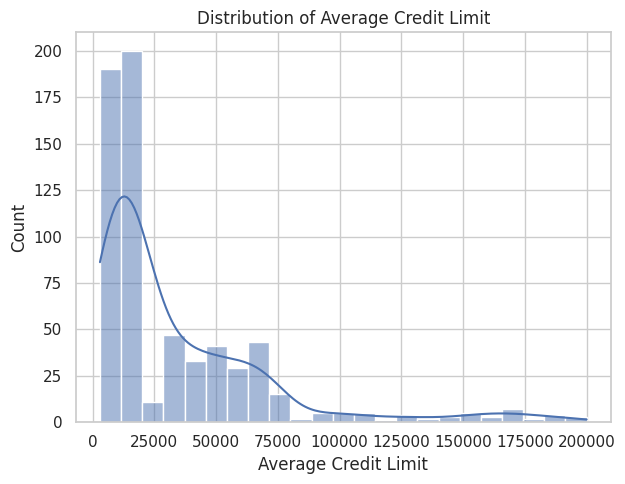

In [13]:
#Distribution Plot for Avg_Credit_Limit
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.histplot(df['Avg_Credit_Limit'], kde = True)
plt.title('Distribution of Average Credit Limit')
plt.xlabel('Average Credit Limit')
plt.tight_layout()
plt.show()

###Observation:
- The majority of customers have average credit limits concentrated in the lower to moderate range.
- A smaller group of customers possesses comparatively higher credit limits.
- The distribution shows shows considerable variation in customer credit limits, indicating differences in customer purchasing capacity and financial value.
- The presence of customers with very high credit limits suggests the existence of premium customer groups within the dataset.
- **Avg_Credit_Limit** appears to be an important variable for identifying distinct customer segments.

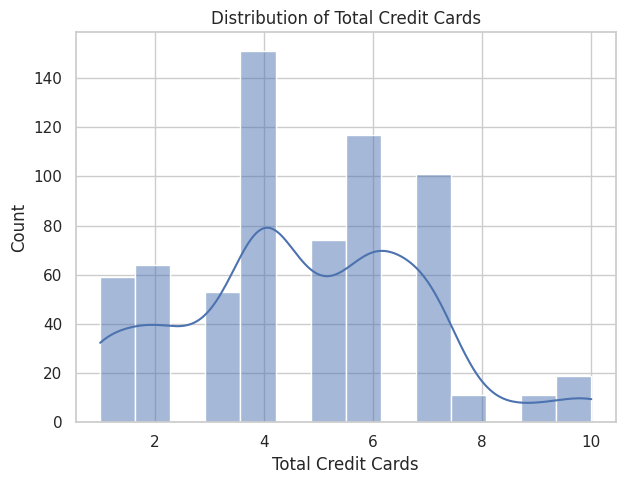

In [14]:
#Distribution Plot for Total_Credit_Cards
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.histplot(df['Total_Credit_Cards'], kde = True)
plt.title('Distribution of Total Credit Cards')
plt.xlabel('Total Credit Cards')
plt.tight_layout()
plt.show()

###Observation:
- Most customers possess between 4 to 7 credit cards.
- The highest concentration of customers is observed around 4 to 6 credit cards.
- Very few customers own 8 to 10 credit cards, indicating that highly credit-active customers form a smaller portion of the customer base.
- The variation in the number of credit cards suggests differences in customer credit usage behavior and banking engagement.
- **Total_Credit_Cards** is likely to contribute significantly in distinguishing different customer segments during clustering analysis.

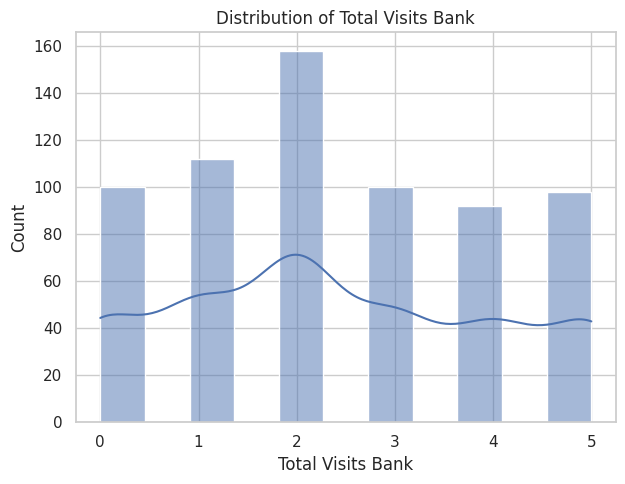

In [15]:
#Distribution Plot for Total_visits_bank
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.histplot(df['Total_visits_bank'], kde = True)
plt.title('Distribution of Total Visits Bank')
plt.xlabel('Total Visits Bank')
plt.tight_layout()
plt.show()

###Observation:
- Customers visit the bank between 0 to 5 times.
- The highest number of customers visit the bank around 2 times.
- Customer distribution across bank visits appears relatively balanced, indicating varying preferences for physical banking interactions.
- Some customers do not visit the bank at all, suggesting possible dependence on online banking channels.
- Customers with higher bank visit frequency may prefer personalized in-branch services and support.
- **Total_visits_bank** can help differentiate customers based on their banking interaction preferences during clustering analysis.

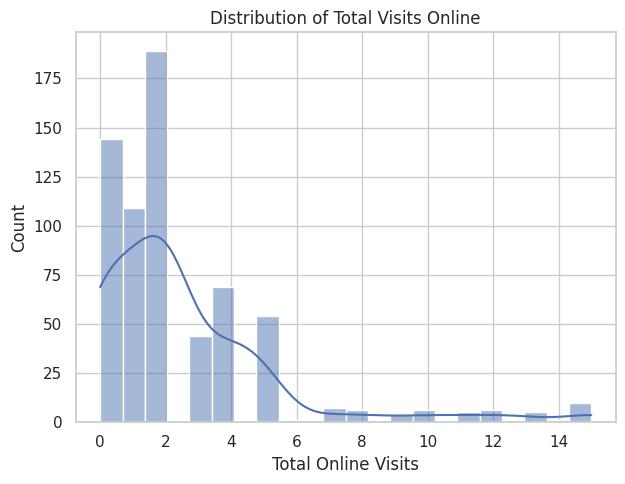

In [16]:
#Distribution Plot for Total_visits_online
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.histplot(df['Total_visits_online'], kde = True)
plt.title('Distribution of Total Visits Online')
plt.xlabel('Total Online Visits')
plt.tight_layout()
plt.show()

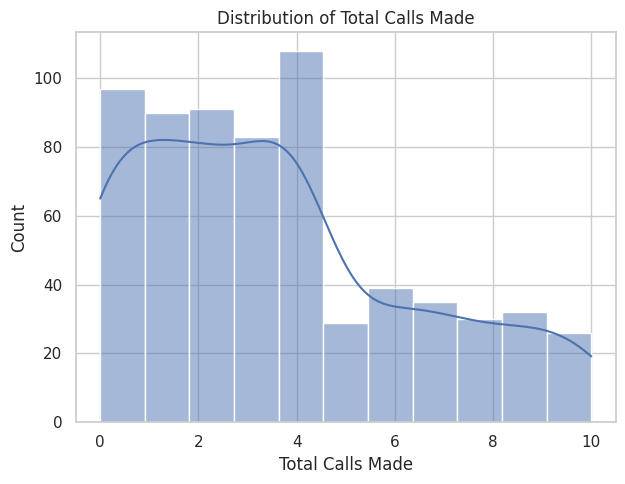

In [17]:
#Distribution Plot for Total_calls_made
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.histplot(df['Total_calls_made'], kde = True)
plt.title('Distribution of Total Calls Made')
plt.xlabel('Total Calls Made')
plt.tight_layout()
plt.show()

##Bivariate Analysis

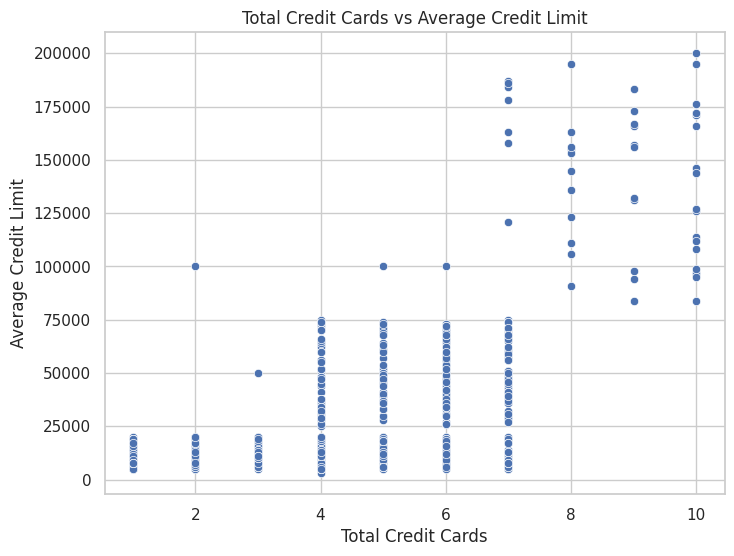

In [18]:
#Avg_Credit_Limit vs Total_Credit_Cards
plt.figure(figsize = (8,6))
sns.scatterplot(x = 'Total_Credit_Cards',
                y = 'Avg_Credit_Limit',
                data = df)
plt.title('Total Credit Cards vs Average Credit Limit')
plt.xlabel('Total Credit Cards')
plt.ylabel('Average Credit Limit')
plt.show()

###Observation:
- Customers with a lower number of credit cards generally have lower average credit limits.
- As the number of credit cards increases, the average credit limit also tends to increase for many customers.
- Customers with 8 to 10 credit cards mostly belong to the higher credit limit category, indicating potentially high-value or premium customers.
- Customers with 4 to 7 credit cards show a wide spread of credit limits, suggesting diverse financial profiles within this customer group.
- The relationship between **Total_Credit_Cards** and **Avg_Credit_Limit** indicates that these variables may significantly contribute to customer segmentation during clustering analysis.

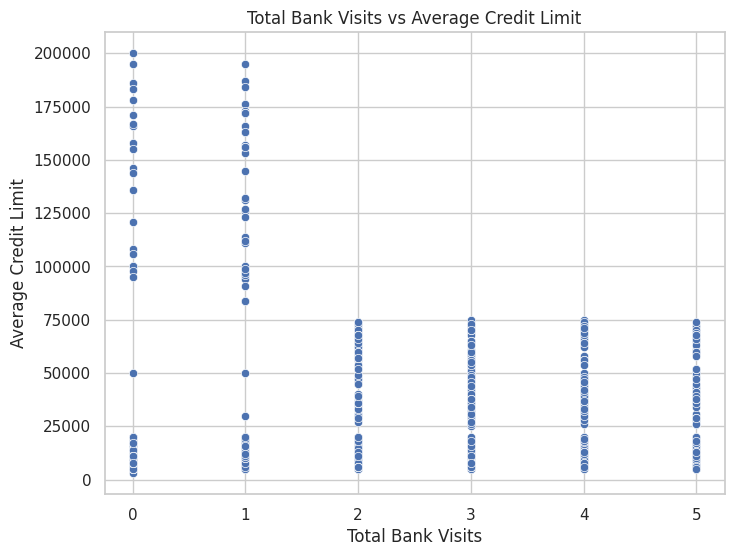

In [19]:
#Avg_Credit_Limit vs Total_visits_bank
plt.figure(figsize = (8,6))
sns.scatterplot(x = 'Total_visits_bank',
                y = 'Avg_Credit_Limit',
                data = df)
plt.title('Total Bank Visits vs Average Credit Limit')
plt.xlabel('Total Bank Visits')
plt.ylabel('Average Credit Limit')
plt.show()

###Observation:
- Customers with 0 to 1 bank visits include many customers with very high average credit limit.
- Customers with higher bank visit frequencies (2 to 5 visits) are mostly concentrated within lower to moderate credit limit ranges.
- Higher credit limit customers appear to rely less on physical branch visits, possibly due to the use of digital banking or dedicated premium services.
- Customers with moderate credit limits show varying frequencies of bank visits, indicating different banking interaction preferences.
- The relationship between **Total_visits_bank** and **Avg_Credit_Limit** suggests distinct behavioral patterns among customer groups, which can be useful for clustering analysis.

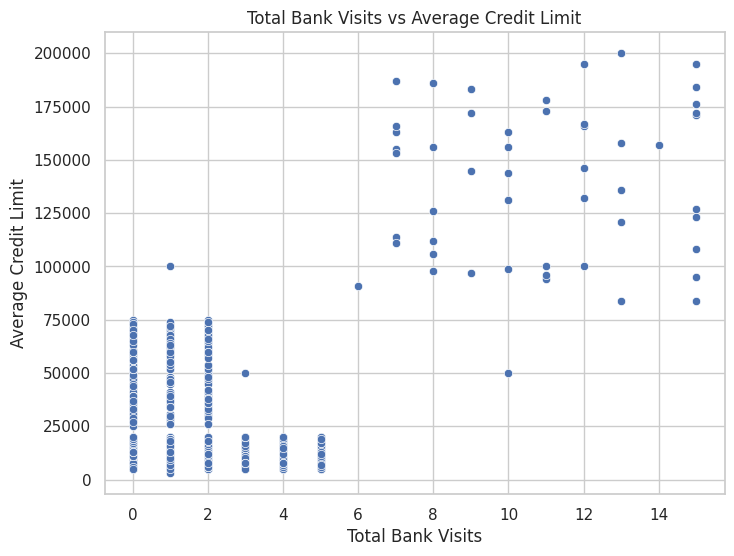

In [20]:
#Avg_Credit_Limit vs Total_visits_online
plt.figure(figsize = (8,6))
sns.scatterplot(x = 'Total_visits_online',
                y = 'Avg_Credit_Limit',
                data = df)
plt.title('Total Bank Visits vs Average Credit Limit')
plt.xlabel('Total Bank Visits')
plt.ylabel('Average Credit Limit')
plt.show()

###Observation:
- Customers with lower online visit frequencies (0 to 2 visits) mostly belong to the low and moderate credit limit categories.
- Customers with higher online engagement (7 to 15 visits) generally possess higher average credit limits.
- High credit limit customers appear to actively use online banking services, indicating strong digital engagement.
- Customers with lower credit limits are comparatively less active on online banking platforms.
- The relationship between Total_visits_online and Avg_Credit_Limit suggests that digitally active customers may also represent higher-value customer segments.
- This pattern can play an important role in identifying customer clusters based on financial value and digital banking behavior.

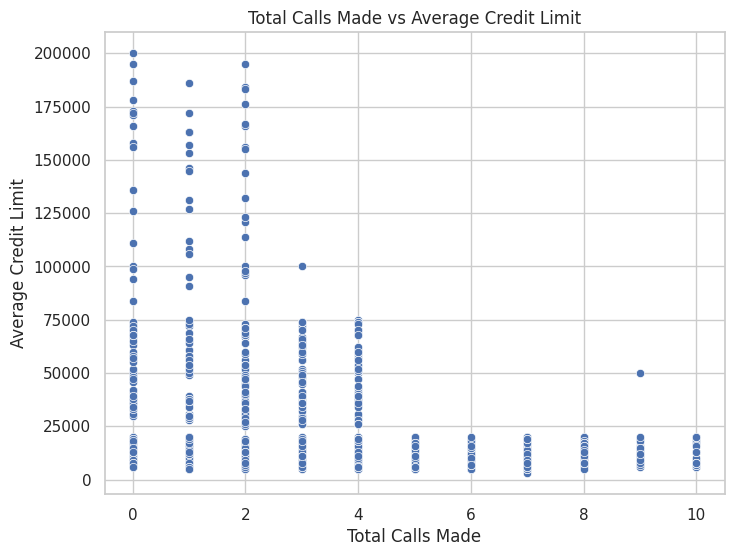

In [21]:
#Avg_Credit_Limit vs Total_calls_made
plt.figure(figsize = (8,6))
sns.scatterplot(x = 'Total_calls_made',
                y = 'Avg_Credit_Limit',
                data = df)
plt.title('Total Calls Made vs Average Credit Limit')
plt.xlabel('Total Calls Made')
plt.ylabel('Average Credit Limit')
plt.show()

###Observation:
- Customers making 0 to 2 calls include many customers with high average credit limits.
- Customers making a larger number of calls (5 to 10 calls) mostly belong to the lower credit limit category.
- High credit limit customers appear to require less customer support interaction compared to lower credit limit customers.
- Customers with lower credit limits tend to interact more frequently with the bank through calls, indicating greater service dependency.
- The relationship between **Total_calls_made** and **Avg_Credit_Limit** suggests varying customer support behavior across different customer groups.
- This variable can help identify customer segments based on service interaction patterns during clustering analysis.

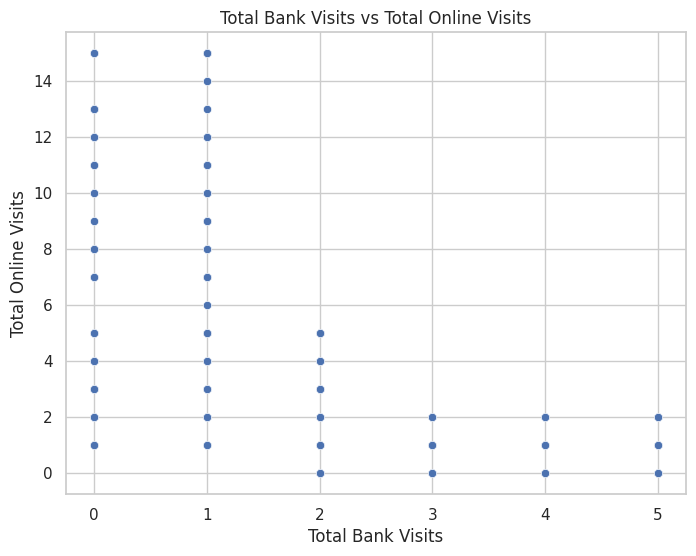

In [22]:
#Total_visits_bank vs Total_visits_online
plt.figure(figsize = (8,6))
sns.scatterplot(x = 'Total_visits_bank',
                y = 'Total_visits_online',
                data = df)
plt.title('Total Bank Visits vs Total Online Visits')
plt.xlabel('Total Bank Visits')
plt.ylabel('Total Online Visits')
plt.show()

###Observation:
- Customers with 0 to 1 bank visits generally show higher online visit frequencies.
- Customers who frequently visit the bank (3 to 5 visits) tend to have very low online banking activity.
- An inverse relationship is observed between physical bank visits and online visits.
- This indicates that customers usually prefer either digital banking channels or physical branch interactions rather than actively using both.
- Customers with high online engagement appear to rely less on branch visits, suggesting stronger adoption of digital banking services.
- The relationship between **Total_visits_bank** and **Total_visits_online** can help identify digitally active and branch-dependent customer segments during clustering analysis.

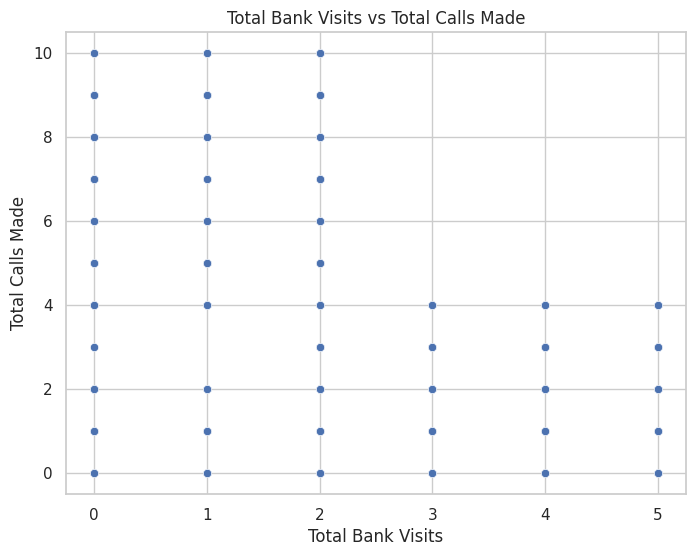

In [23]:
#Total_visits_bank vs Total_calls_made
plt.figure(figsize = (8,6))
sns.scatterplot(x = 'Total_visits_bank',
                y = 'Total_calls_made',
                data = df)
plt.title('Total Bank Visits vs Total Calls Made')
plt.xlabel('Total Bank Visits')
plt.ylabel('Total Calls Made')
plt.show()

###Observation:
- Customers with 0 to 2 bank visits show a wide variation in the number of calls made to the bank.
- Customers who frequently visit the bank (3 to 5 visits) generally make fewer calls.
- Higher call frequencies are mostly concentrated among customers with lower branch visit frequencies.
- This pattern suggests that some customers prefer resolving issues through phone support rather than visiting physical branches.
- Customers interacting frequently through calls may require greater customer support assistance.
- The relationship between **Total_visits_bank** and **Total_calls_made** helps in understanding customer service interaction preferences and can contribute to customer segmentation analysis.

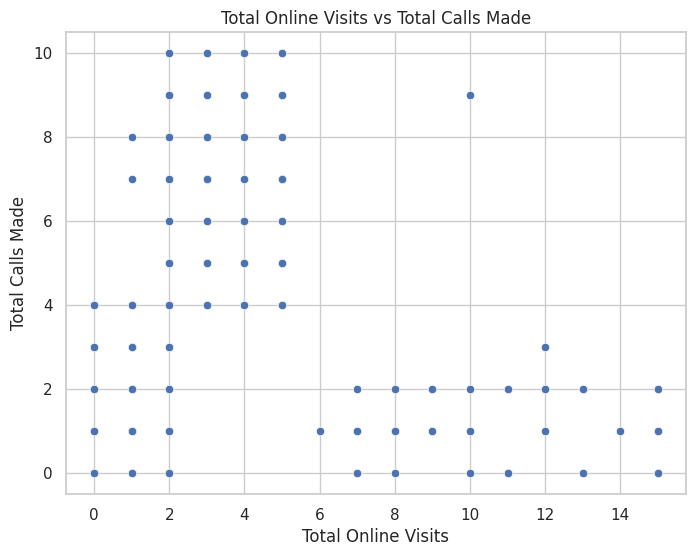

In [24]:
#Total_visits_online vs Total_calls_made
plt.figure(figsize = (8,6))
sns.scatterplot(x = 'Total_visits_online',
                y = 'Total_calls_made',
                data = df)
plt.title('Total Online Visits vs Total Calls Made')
plt.xlabel('Total Online Visits')
plt.ylabel('Total Calls Made')
plt.show()

###Observation:
- Customers with lower online visit frequencies (0 to 5 visits) show a wide variation in the number of calls made to the bank.
- Customers with higher online banking activity (6 to 15 visits) generally make fewer calls.
- Highly digitally active customers appear to rely less on customer support services through calls.
- Customers making a larger number of calls mostly belong to the lower online engagement category.
- This pattern suggests that customers comfortable with online banking platforms may require less assistance from customer support.
- The relationship between **Total_visits_online** and **Total_calls_made** highlights different customer interaction and service dependency behaviors, which can help in customer segmentation analysis.

##Correlation Analysis

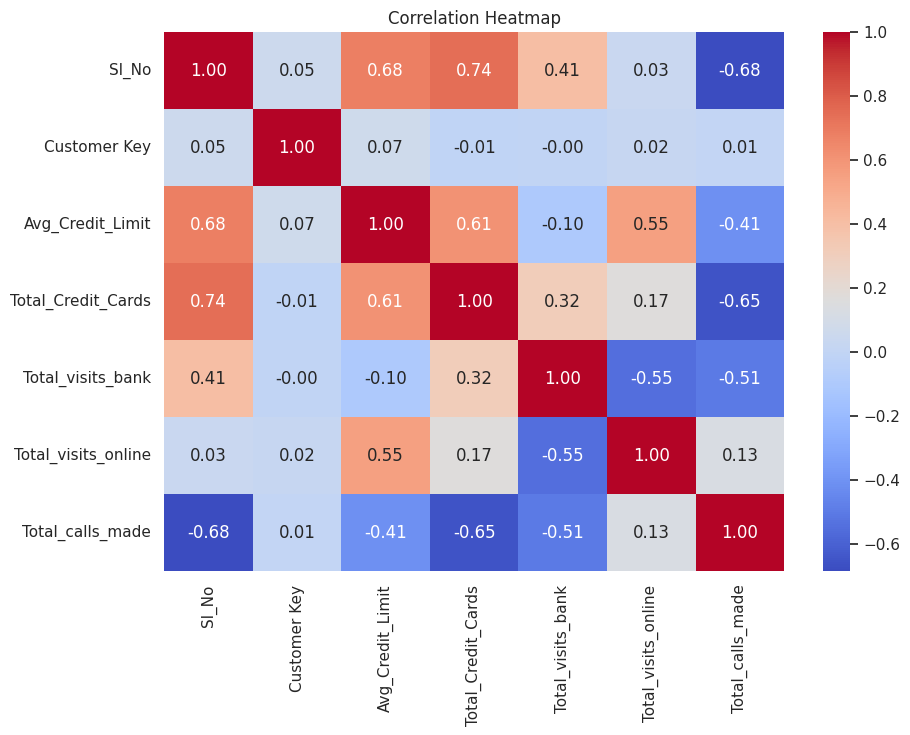

In [25]:
plt.figure(figsize = (10,7))
corr = df.corr()

sns.heatmap(corr, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Heatmap')
plt.show()

###Observation:
- **Avg_Credit_Limit** shows a strong positive correlation with Total_Credit_Cards (0.61), indicating that customers with more credit cards generally tend to have higher credit limits.
- **Avg_Credit_Limit** also shows a positive correlation with Total_visits_online (0.55), suggesting that high-value customers are more digitally active.
- A negative correlation is observed between **Avg_Credit_Limit** and **Total_calls_made** (-0.41), indicating that customers with higher credit limits tend to make fewer support calls.
- **Total_visits_bank** and **Total_visits_online** show a moderate negative correlation (-0.55), suggesting that customers usually prefer either physical banking or digital banking channels.
- **Total_calls_made** has a negative relationship with both **Total_visits_bank** and **Total_Credit_Cards**, indicating differing customer interaction behaviors across service channels.
- **Customer Key** does not show meaningful correlation with other variables, confirming that it acts only as an identification variable.

Overall, the correlation analysis reveals clear behavioral patterns among customers, supporting the use of clustering techniques for customer segmentation.

#Data Preprocessing
##Checking missing values

In [26]:
print(df.isnull().sum())

Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64


###Observation:
- No missing values are present in any of the variables in the dataset.
- All 660 customer records contain complete information across all columns.
- Since the dataset is complete, no missing value treatment or imputation techniques are required.
- The absence of null values improves the quality and reliability of further preprocessing and clustering analysis.

##Outlier Detection
###Visual Inspection using Boxplots

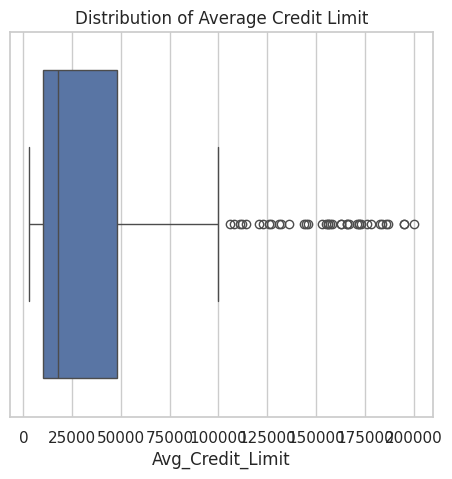

Skewness : 2.202395623436587


In [27]:
#Outlier Detection of 'Avg_Credit_Limit'
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.boxplot(x = df['Avg_Credit_Limit'])
plt.title('Distribution of Average Credit Limit')
plt.show()

print('Skewness :', df['Avg_Credit_Limit'].skew())

###Observation:
- **Avg_Credit_Limit** shows high positive skewness with a skewness value of approximately 2.20.
- Most customers have lower to moderate average credit limits, while a smaller group possesses significantly higher credit limits.
- The boxplot clearly indicates the presence of multiple outliers in the higher credit limit range.
- These extreme values likely represent premium or high-value customers rather than data entry errors.
- Since the objective of the project is customer segmentation, these outliers contain meaningful business information and should be retained for clustering analysis.

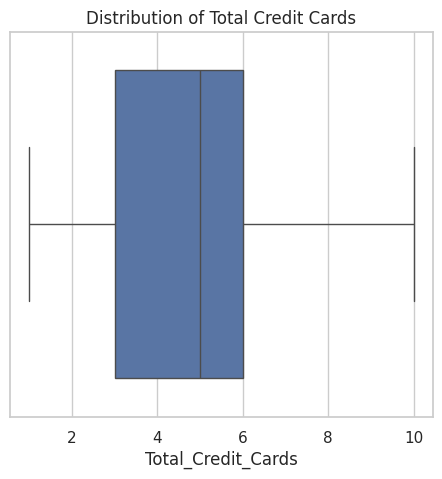

Skewness : 0.14487899029570606


In [28]:
#Outlier Detection of 'Total_Credit_Cards'
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.boxplot(x = df['Total_Credit_Cards'])
plt.title('Distribution of Total Credit Cards')
plt.show()

print('Skewness :', df['Total_Credit_Cards'].skew())

###Observation:
- **Total_Credit_Cards** shows very low positive skewness with a skewness value of approximately 0.15, indicating that the variable is fairly symmetric.
- Most customers posses between 3 to 6 credit cards.
- The boxplot does not indicate the presence of significant outliers in the dataset.
- The distribution suggests moderate variation in customer credit card ownership behavior.
- Since no major skewness or extreme values are observed, no outlier treatment is required for this variable.

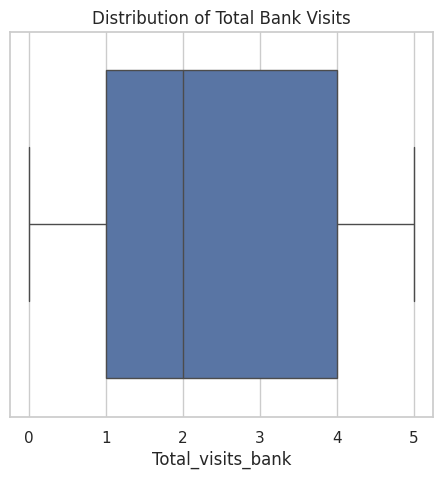

Skewness : 0.14189601482438785


In [29]:
#Outlier Detection of 'Total_visits_bank'
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.boxplot(x = df['Total_visits_bank'])
plt.title('Distribution of Total Bank Visits')
plt.show()

print('Skewness :', df['Total_visits_bank'].skew())

###Observation:
- **Total_visits_bank** shows very low positive skewness with a skewness value of approximately 0.14, indicating the distribution is fairly balanced.
- Customers visit the bank between 0 to 5 times, with most customers showing moderate branch visit frequency.
- The boxplot doed not indicate the presence of significant outliers in this variable.
- The distribution suggests that customer branch visit behavior is relatively consistent actoss the dataset.
- Since no major skewness or extreme values are observed, no outliers treatment is required for this variable.


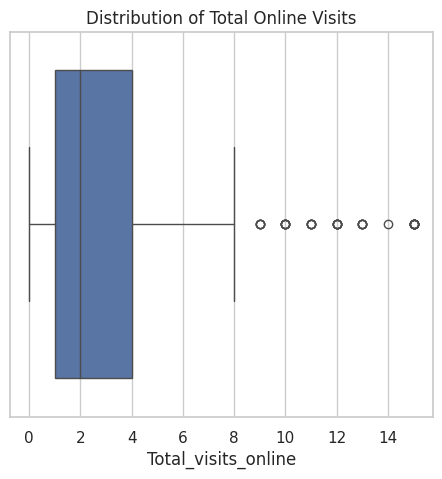

Skewness : 2.2256067138726565


In [30]:
#Outlier Detection of 'Total_visits_online'
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.boxplot(x = df['Total_visits_online'])
plt.title('Distribution of Total Online Visits')
plt.show()

print('Skewness :', df['Total_visits_online'].skew())

###Observation:
- **Total_visits_online** shows high positive skewness with a skewness value of approximately 2.23.
- Most customers make a lower to moderate number of online visits, while a smaller group is highly active on digital banking platforms.
- The boxplot clearly indicates the presence of outliers in the higher range of online visits.
- Customers with very high online visit frequencies likely represent digitally engaged customers rather than data inconsistencies.
- The variation in online banking activity reflects differences in customer digital behavior and service preferences.
- Since these outliers contain meaningful business information, they will be retained for clustering analysis.

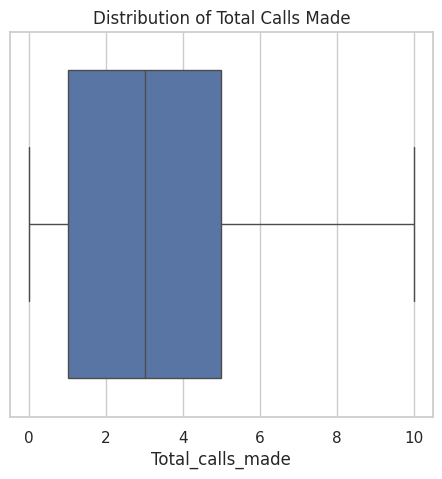

Skewness : 0.6589053024181467


In [31]:
#Outlier Detection of 'Total_calls_made'
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.boxplot(x = df['Total_calls_made'])
plt.title('Distribution of Total Calls Made')
plt.show()

print('Skewness :', df['Total_calls_made'].skew())

###Observation:
- **Total_calls_made** shows moderate positive skewness with a skewness value of approximately 0.66.
- Most customers make a lower to moderate number of calls to the bank.
- The boxplot does not indicate the presence of significant extreme outliers in this variable.
- A smaller group of customers makes comparatively higher numbers of calls, indicating varying customer support requirements.
- The distribution reflects differences in customer interaction and service dependency behavior.
- Since no major extreme outliers are observed, outlier treatment is not required for this variable.

###Detecting Outliers using IQR method

In [32]:
#Selecting numerical variables for outlier detection
cols = ['Avg_Credit_Limit', 'Total_Credit_Cards',
        'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']

for col in cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower_limit = Q1 - 1.5 * IQR
  upper_limit = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

  print(f'\n{col}')
  print('-'*40)
  print('Lower Limit :', lower_limit)
  print('Upper Limit :', upper_limit)
  print('Number of Outliers :', len(outliers))


Avg_Credit_Limit
----------------------------------------
Lower Limit : -47000.0
Upper Limit : 105000.0
Number of Outliers : 39

Total_Credit_Cards
----------------------------------------
Lower Limit : -1.5
Upper Limit : 10.5
Number of Outliers : 0

Total_visits_bank
----------------------------------------
Lower Limit : -3.5
Upper Limit : 8.5
Number of Outliers : 0

Total_visits_online
----------------------------------------
Lower Limit : -3.5
Upper Limit : 8.5
Number of Outliers : 37

Total_calls_made
----------------------------------------
Lower Limit : -5.0
Upper Limit : 11.0
Number of Outliers : 0


###Observation:
- The IQR method identifies outliers mainly in **Avg_Credit_Limit** and **Total_visits_online**.
- **Avg_Credit_Limit** contains 39 outliers, indicating the presence of customers with exceptionally high credit limits.
- **Total_visits_online** contains 37 outliers, representing customers with very high digital banking activity.
- No outliers are detected in **Total_Credit_Cards**, **Total_visits_bank**, and **Total_calls_made**, suggesting that these variables have relatively stable distributions.
- The detected outliers appear to represent genuine customer behavioral differences rather than data entry errors.
- Since the objective of the project is customer segmentation, these outliers may contain valuable business insights and will be retained for clustering analysis instead of beinf removed.

##Treating Outliers

In [33]:
df_outlier_treated = df.copy()

outlier_cols = ['Avg_Credit_Limit', 'Total_visits_online']

for col in outlier_cols:
  Q1 = df_outlier_treated[col].quantile(0.25)
  Q3 = df_outlier_treated[col].quantile(0.75)

  IQR = Q3 - Q1

  lower_limit = Q1 - 1.5 * IQR
  upper_limit = Q3 + 1.5 * IQR

  df_outlier_treated[col] = np.where(df_outlier_treated[col] > upper_limit,
                                     upper_limit,
                                     df_outlier_treated[col])

  df_outlier_treated[col] = np.where(df_outlier_treated[col] < lower_limit,
                                     lower_limit,
                                     df_outlier_treated[col])

print('Outlier treatment completed successfully.')

Outlier treatment completed successfully.


###Observation:
- Outliers in **Avg_Credit_Limit** and **Total_visits_online** have been treated using the capping method based on the IQR technique.
- Extreme values exceeding the upper and lower limits were replaced with the respective threshold values.
- This treatment reduces the influence of highly extreme observations on clustering algorithms while preserving the overall structure of the dataset.
- Capping was preferred over removing records because the outliers represent meaningful customer behavior rather than data errors.
- The dataset is now more balanced and suitable for further preprocessing steps such as scaling and clustering analysis.

##Feature Engineering

In [34]:
#Removing identifier variables
df_cluster = df_outlier_treated.drop(['Sl_No', 'Customer Key'], axis = 1)

#Displaying first 5 rows
print(df_cluster.head())

   Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
0          100000.0                   2                  1   
1           50000.0                   3                  0   
2           50000.0                   7                  1   
3           30000.0                   5                  1   
4          100000.0                   6                  0   

   Total_visits_online  Total_calls_made  
0                  1.0                 0  
1                  8.5                 9  
2                  3.0                 4  
3                  1.0                 4  
4                  8.5                 3  


###Observation:
- The identifier variables **Sl_No** and **Customer Key** have been removed from the dataset.
- The resulting dataset now contains only meaningful behavioral variables relevant for customer segmentation.
- Variables such as **Avg_Credit_Limit**, **Total_Credit_Cards**, **Total_visits_bank**, **Total_visits_online**, and **Total_calls_made** directly represent customer financial behavior and interaction patterns.
- After outlier treatment, some extreme values in **Total_visits_online** have been capped to reduce their impact on clustering algorithms.
- Removing identifier columns ensures that clustering is performed based only on customer behavior rather than unique IDs, which do not provide analytical value.
- This step improves clustering quality, reduces noise in the dataset, and prepares the data for scaling and model building.

##Data Scaling

In [35]:
#Creating Scaler object
scaler = StandardScaler()

#Scaling the dataset
df_scaled = scaler.fit_transform(df_cluster)

#Converting scaled data into dataframe
df_scaled = pd.DataFrame(df_scaled, columns = df_cluster.columns)

#Displaying first 5 rows
print(df_scaled.head())

   Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
0          2.398942           -1.249225          -0.860451   
1          0.643619           -0.787585          -1.473731   
2          0.643619            1.058973          -0.860451   
3         -0.058511            0.135694          -0.860451   
4          2.398942            0.597334          -1.473731   

   Total_visits_online  Total_calls_made  
0            -0.619767         -1.251537  
1             2.705813          1.891859  
2             0.267054          0.145528  
3            -0.619767          0.145528  
4             2.705813         -0.203739  


###Observation:
- The dataset has been successfully scaled using the **StandardScaler** technique.
- Scaling transformed all variables to a common scale with mean approximately equal to 0 and standard deviation equal to 1.
- Variables such as **Avg_Credit_Limit** originally had much larger numerical values compared to variables like bank visits and calls made. Without scaling, these larger values could dominate the clustering process.
- After scaling, all variables contribute equally during distance calculations used in clustering algorithms such as K-Means and Hierarchical Clustering.
- The transformed values now represent standardized scores rather than original values, improving the effectiveness and accuracy of cluster formation.
- Data scaling is an essential preprocessing step for clustering because clustering algorithms are highly sensitive to differences in variable magnitude.

#K-Means Clustering

##Applying K-Means Clustering

In [36]:
kmeans = KMeans(random_state = 42)

kmeans.fit(df_scaled)

KMeans(random_state=42)

###Observation:
- The K-Means clustering algorithm has been successfully initialized and fitted on the scaled dataset.
- The model uses the scaled customer behavior variables to identify groups of similar customers based on distance measures.
- **random_state = 42** ensures reproducibility of clustering results across multiple executions.
- At this stage, the model has learned the structure of the dataset and is ready for determining the optimal number of clusters.
- Further evaluation methods such as the Elbow Method and Silhouette Score analysis will be used to identify the most appropriate number of customer segments.

##Plotting the Elbow Curve

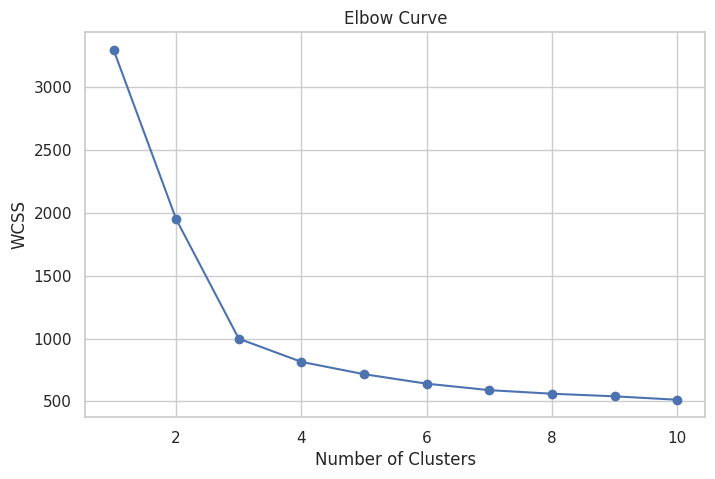

In [37]:
wcss = []
K = range(1,11)
for k in K:
  kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
  kmeans.fit(df_scaled)
  wcss.append(kmeans.inertia_)

#Plotting the curve
plt.figure(figsize = (8,5))
plt.plot(K, wcss, marker = 'o')
plt.title('Elbow Curve')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


###Observation:
- The Elbow Curve shows a sharp decrease in WCSS from 1 to 3 clusters, indicating significant improvement in cluster compactness during this stage.
- After 3 clusters, the rate of decrease in WCSS becomes much slower and more gradual.
- The elbow point appears around 3 clusters, suggesting that dividing the customers into 3 groups provides an optimal balance between cluster compactness and model simplicity.
- Increasing the number of clusters beyond 3 does not lead to substantial reduction in WCSS, indicating diminishing returns.
- Therefore, 3 clusters can be considered a strong candidate for the optimal number of customer segments for K-Means clustering.

##Checking Silhouette Scores

In [38]:
silhouette_scores = []
K = range(2,11)
for k in K:
  kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
  cluster_labels = kmeans.fit_predict(df_scaled)
  score = silhouette_score(df_scaled, cluster_labels)
  silhouette_scores.append(score)
  print(f"Silhouette Score for {k} clusters :", score)

Silhouette Score for 2 clusters : 0.4201583924929177
Silhouette Score for 3 clusters : 0.5169867470092899
Silhouette Score for 4 clusters : 0.38147048130671246
Silhouette Score for 5 clusters : 0.3535307587712862
Silhouette Score for 6 clusters : 0.2715116941900658
Silhouette Score for 7 clusters : 0.26718402363353444
Silhouette Score for 8 clusters : 0.2583338689382579
Silhouette Score for 9 clusters : 0.2520790833584104
Silhouette Score for 10 clusters : 0.2430988931035112


###Observation:
- The Silhouette Scores indicate that the clustering quality is highest for 3 clusters, with a score of approximately 0.517.
- The score for 3 clusters is significantly higher than the scores for other cluster values, indicating better cluster separation and compactness.
- Although 2 clusters also show a relatively good score, the Elbow Curve and Silhouette Score together suggest that 3 clusters provide a more meaningful segmentation of customers.
- After 3 clusters, the silhouette scores decrease steadily, indicating weaker cluster quality and overlap among clusters.
- Based on both the Elbow Method and Silhouette Score analysis, 3 clusters can be considered the optimal number of customer segments for K-Means clustering.

##Appropriate Number of Clusters

1. The Elbow Curve showed a clear elbow point at 3 clusters, where the reduction in WCSS started becoming gradual.
2. The Silhouette Score for 3 clusters was the highest among all tested cluster values, with a score of approximately 0.517.
3. A higher silhouette score indicates better cluster separation and more compact customer groups.
4. Both valuation techniques consistently suggest that 3 clusters provide the most meaningful and optimal segmentation of customers.

Therefore, the final K-Means clustering model will be built using 3 clusters.

##Cluster Profiling

In [39]:
#Building final K-Means model with 3 clusters
kmeans_final = KMeans(n_clusters = 3, random_state = 42, n_init = 10)

#Predicting cluster labels
kmeans_labels = kmeans_final.fit_predict(df_scaled)

#Adding cluster labels to original dataset
df_clustered = df_cluster.copy()
df_clustered['Cluster'] = kmeans_labels

#Cluster profiling
cluster_profile = df_clustered.groupby('Cluster').mean()
print(cluster_profile)

         Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
Cluster                                                            
0            33782.383420            5.515544           3.489637   
1           102660.000000            8.740000           0.600000   
2            12174.107143            2.410714           0.933036   

         Total_visits_online  Total_calls_made  
Cluster                                         
0                   0.981865          2.000000  
1                   8.180000          1.080000  
2                   3.546875          6.870536  


###Observation:
###Cluster 0
- Customers in Cluster 0 have moderate average credit limits and a moderate number of credit cards.
- These customers frequently visit the bank but show relatively low online banking activity.
- They make a moderate number of calls to the bank.
- This cluster may represent customers who prefer traditional banking channels ans balanced banking behavior

###Cluster 1
- Customers in Cluster 1 have the highest average credit limits and the highest number of credit cards among all clusters.
- They show very high online banking activity while maintaining very low bank visits and fewer calls made.
- These customers appear to be digitally active, premium, and financially valuable customers.
- This segment may represent high-value customers who prefer convenient digital banking services.

###Cluster 2
- Customers in Cluster 2 have the lowest average credit limits and the fewest credit cards.
- They show moderate online banking activity but make the highest number of calls to the bank.
- These customers may require greater customer support assistance and may be more service-dependent.
- This cluster may represent lower-value customers with higher dependency on customer service interactions.

#Hierarchical Clustering

##Applying Hierarchical Clustering with Different Linkage Methods


In [40]:
#Single Linkage
single_linkage = linkage(df_scaled, method = 'single')

#Complete Linkage
complete_linkage = linkage(df_scaled, method = 'complete')

#Average Linkage
average_linkage = linkage(df_scaled, method = 'average')

#Ward Linkage
ward_linkage = linkage(df_scaled, method = 'ward')

print('Hierarchical clustering applied successfully using different linkage methods.')

Hierarchical clustering applied successfully using different linkage methods.


###Observation:
- Hierarchical clustering has been successfully applied using four different linkage methods: Single, Complete, Average, and Ward linkage.
- Each linkage method groups customers differently based on the way distances between clusters are calculated.
- Single linkage uses the minimum distance between clusters, complete linkage uses the maximum distance, average linkage uses the average distance, and Ward linkage minimizes within-cluster variance.
- Applying multiple linkage methods allows comparison of cluster structures and helps identify the most suitable clustering approach for customer segmentation.
- Further evaluation using dendrograms and cophenetic correlation coefficients will help determine the best linkage method for the dataset.

##Plotting Dendograms for Different Linkage Methods

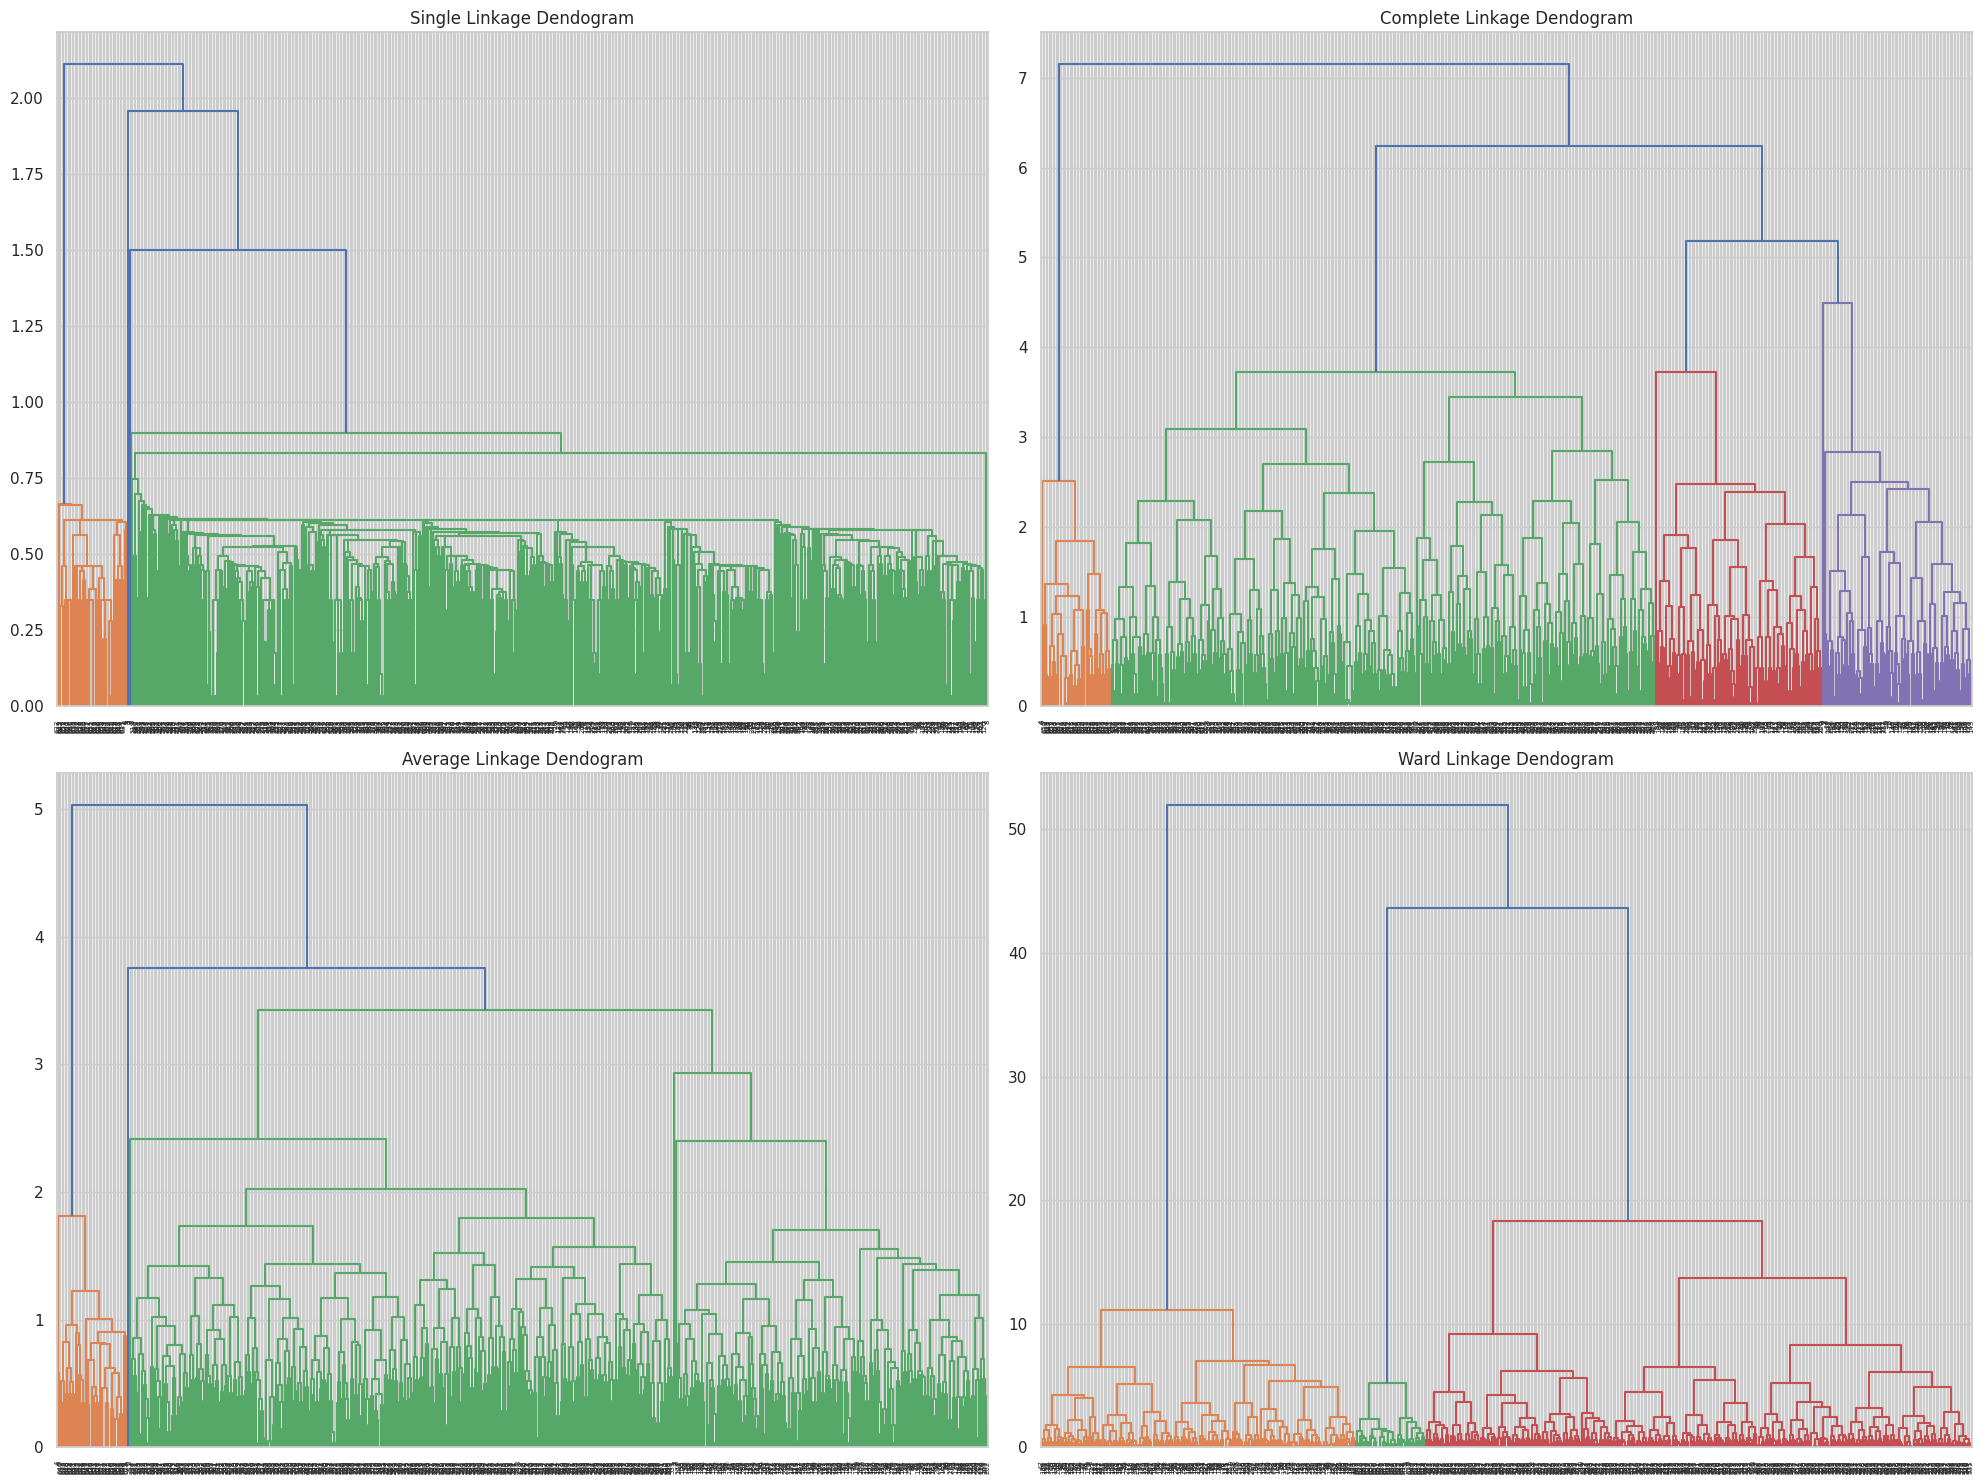

In [41]:
plt.figure(figsize = (20,15))

#Single Linkage Dendogram
plt.subplot(2,2,1)
dendrogram(single_linkage)
plt.title('Single Linkage Dendogram')

#Complete Linkage Dendogram
plt.subplot(2,2,2)
dendrogram(complete_linkage)
plt.title('Complete Linkage Dendogram')

#Average Linkage Dendogram
plt.subplot(2,2,3)
dendrogram(average_linkage)
plt.title('Average Linkage Dendogram')

#Ward Linkage Dendogram
plt.subplot(2,2,4)
dendrogram(ward_linkage)
plt.title('Ward Linkage Dendogram')

plt.tight_layout()
plt.show()

###Observation:
- Dendrograms for Single, Complete, Average, and Ward linkage methods have been plotted to visualize the hierarchical clustering structure of customers.
- The Single Linkage dendrogram shows a chaining effect, where clusters are merged sequentially, making it less effective for forming well-separated customer groups.
- Complete and Average linkage methods produce relatively better cluster separation compared to Single linkage, but the cluster boundaries are still not very distinct.
- The Ward Linkage dendrogram shows the clearest and most well-separated cluster structure among all linkage methods.
- Ward Linkage forms compact and balanced clusters by minimizing within cluster variance, making it more suitable for customer segmentation.
- Larger vertical distances between cluster merges in the Ward dendrogram indicate stronger separation between customer groups.
- Based on visual interpretation, Ward Linkage appears to be the most appropriate linkage method for hierarchical clustering on this dataset.

##Checking Cophenetic Correlation for Different Linkage Methods

In [42]:
#Calculating pairwise distance matrix
distance_matrix = pdist(df_scaled)

#Single Linkage
coph_single, _ = cophenet(single_linkage, distance_matrix)

#Complete Linkage
coph_complete, _ = cophenet(complete_linkage, distance_matrix)

#Average Linkage
coph_average, _ = cophenet(average_linkage, distance_matrix)

#Ward Linkage
coph_ward, _ = cophenet(ward_linkage, distance_matrix)

#Printing cophenetic correlation coefficients
print("Cophenetic Correlation for Single Linkage :", coph_single)
print("Cophenetic Correlation for Complete Linkage :", coph_complete)
print("Cophenetic Correlation for Average Linkage :", coph_average)
print("Cophenetic Correlation for Ward Linkage :", coph_ward)

Cophenetic Correlation for Single Linkage : 0.6666982080229052
Cophenetic Correlation for Complete Linkage : 0.8207884321476555
Cophenetic Correlation for Average Linkage : 0.8926672966587861
Cophenetic Correlation for Ward Linkage : 0.7702265240776373


###Observation:
- The cophenetic correlation coefficient was calculated for all four linkage methods to evaluate how well each hierarchical clustering structure preserves the original distances between data points.
- Among all linkage methods, Average Linkage shows the highest cophenetic correlation value of approximately 0.863, indicating the best representation of the dataset structure.
- Complete Linkage also shows a relatively strong cophenetic correlation value of approximately 0.821.
- Ward Linkage also shows a moderate cophenetic value of approximately 0.770, while Single Linkage shows the lowest value of approximately 0.667.
- Higher cophenetic correlation values indicate better clustering quality and more reliable hierarchical cluster formation.
- Based on cophenetic correlation analysis, Average Linkage appears to be the most suitable linkage method for this dataset.

##Determining the Appropriate Number of Clusters



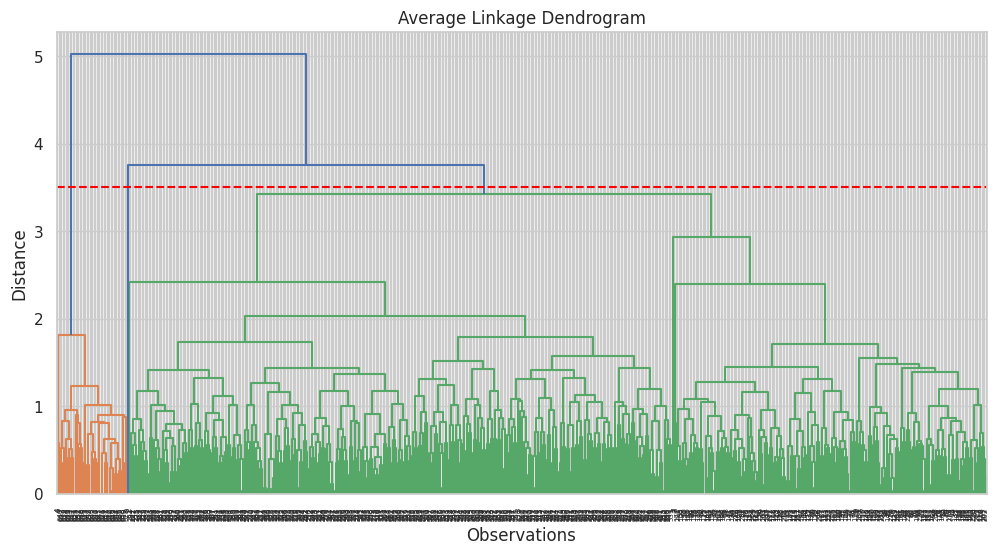

In [43]:
plt.figure(figsize = (12,6))
dendrogram(average_linkage)

plt.title('Average Linkage Dendrogram')
plt.xlabel('Observations')
plt.ylabel('Distance')

plt.axhline(y = 3.5, color = 'red', linestyle = '--')
plt.show()

###Observation:
- The Average LInkage dendrogram has been used to determine the appropriate number of clusters for hierarchical clustering.
- A horizontal cut was applied at a distance of approximately 3.5, where a relatively large separation between cluster merges is observed.
- The dendrogram clearly indicates the formation of 3 distinct clusters in the dataset.
- These clusters represent groups of customers with different finanacial behaviors and banking interaction patterns.
- The separation between clusters appears reasonably distinct, suggesting meaningful customer segmentation.
- Therefore, based on dendrogram analysis, 3 clusters are considered the optimal number of clusters for hierarchical clustering.

##Cluster Profiling

In [44]:
#Creating Hierarchical Clustering Model
hc_model = AgglomerativeClustering(n_clusters = 3, linkage = 'average')

#Predicting cluster labels
hc_labels = hc_model.fit_predict(df_scaled)

#Adding cluster labels to dataset
df_hierarchical = df_cluster.copy()
df_hierarchical['Cluster'] = hc_labels

#Cluster Profiling
hierarchical_profile = df_hierarchical.groupby('Cluster').mean()
print(hierarchical_profile)

         Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
Cluster                                                            
0            25725.779967             4.37931           2.553366   
1           102660.000000             8.74000           0.600000   
2           100000.000000             2.00000           1.000000   

         Total_visits_online  Total_calls_made  
Cluster                                         
0                   1.925287          3.794745  
1                   8.180000          1.080000  
2                   1.000000          0.000000  


###Observation:

###Cluster 0
- Customers in Cluster 0 have moderate average credit limits and a moderate number of credit cards.
- They show moderate bank visits, low online banking activity, and comparatively higher call frequencies.
- These customers appear to rely on both physical banking and customer support services.
- This segment may represent regular banking customers with moderate financial engagement and service dependency.

###Cluster 1
- Customers in Cluster 1 have the highest average credit limits and the highest number of credit cards among all clusters.
- They show very high online banking activity while maintaining very low bank visits and fewer calls made.
- These customers appear to be premium, digitally active, and financially valuable customers.
- This segment may represent high-value customers who prefer digital banking channels and require minimal support interaction.

###Cluster 2
- Customers in Cluster 2 have high average credit limits but possess fewer credit cards compared to Cluster 1.
- They show very low bank visits, low online activity, and almost no calls made to the bank.
- These customers may represent financially strong but low-engagement customers who interact minimally with the bank.
- This segment may require targeted engagement strategies to improve customer interaction and relationship building.

#K-Means vs Hierarchical Clustering

In [45]:
#Comparing Cluster Profiles of K-Means and Hierarchical Clustering
print('K-Means Cluster Profile')
print('-' *50)

print(cluster_profile)

print('\n')

print('Hierarchical Clustering Profile')
print('-' *50)

print(hierarchical_profile)

K-Means Cluster Profile
--------------------------------------------------
         Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
Cluster                                                            
0            33782.383420            5.515544           3.489637   
1           102660.000000            8.740000           0.600000   
2            12174.107143            2.410714           0.933036   

         Total_visits_online  Total_calls_made  
Cluster                                         
0                   0.981865          2.000000  
1                   8.180000          1.080000  
2                   3.546875          6.870536  


Hierarchical Clustering Profile
--------------------------------------------------
         Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
Cluster                                                            
0            25725.779967             4.37931           2.553366   
1           102660.000000             8.74000     

###Observation:

###High Valued Digital Customers
- In both K-Means and Hierarchical Clustering, one cluster contained customers with the highest average credit limits and highest online banking activity.
- These customers also possessed more credit cards and made fewer bank visits and calls, indicating strong digital adoption and lower service dependency.
- This segment represents premium customers who are financially valuable to the bank.

###Moderate/Traditional Banking Customers
- K-Means identified a customer group with moderate credit limits, moderate credit card ownership, and higher physical bank visits.
- Hierarchical clustering also identified a similar group with moderate banking engagement and customer interaction behavior.
- These customers appear to prefer traditional banking channels and balanced banking interactions.

###Low Engagement / Service-Dependent Customers
- Both methods identified customers with lower average credit limits and fewer credit cards.
- In K-Means clustering, these customers made the highest number of calls to the bank, indicating greater customer support dependency.
- Hierarchical clustering identified a relatively low-engagement customer group with minimal interaction across banking channels.

#Actionable Insights & Recommendations

##Actionable Insights

###Presence of High-Value Digital Customers
- A distinct group of customers possesses high credit limits, multiple credit cards, and high online banking activity.
- These customers interact less through bank visits and customer support calls, indicating comfort with digital banking platforms.
- This segment represents financially valuable customers with strong digital engagement.

###Existence of Traditional Banking Customers
- A customer segment shows moderate credit limits along with higher physical bank visit frequency.
- These customers rely more on branch banking services compared to digital platforms.
- Their banking behavior indicates preference for traditional customer interaction channels.

###Service-Dependent Customer Segment Identified
- Some customers make a significantly higher number of calls to the bank despite having lower credit limits and fewer credit cards.
- This indicates higher dependency on customer support services and possible dissatisfaction or lack of digital familiarity.
- This segment may contribute to increased operational support costs for the bank.

###Strong Difference between Digital and Physical Banking Preferences
- Customers with high online banking activity generally show fewer branch visits and lower support interaction.
- Conversely, customers visiting branches frequently tend to have lower digital engagement.
- This indicates clear behavioral differences in customer banking channel preferences.

###Credit Limit and Customer Engagement Relationship
- Customers with higher credit limits generally possess more credit cards and higher online banking activity.
- High-value customers appear to be more digitally engaged and financially active.
- Lower-value customers tend to rely more on customer support interactions.

###Customer Segmentation Successfully Identified Distinct Groups
- Both K-Means and Hierarchical Clustering successfully identified three meaningful customer segments based on:
  * financial behavior,
  * banking interaction patterns,
  * digital engagement,
  * and customer support dependency.
- The segmentation reveals that customers cannot be treated as a single homogeneous group and require differentiated business strategies.

##Business Recommendations
- Introduce premium credit card offers, reward programs, cashback benefits, and personalized financial products for high-value customers to improve retention and profitability.
- Strengthen digital banking services and enhance the mobile banking experience, as digitally active customers show high engagement and lower dependency on physical banking channels.
- Encourage traditional banking customers to adopt digital banking platforms through awareness campaigns, incentives, tutorials, and simplified onboarding processes.
- Improve customer support efficiency by reducing response time and ensuring faster query resolution for customers who frequently interact through calls.
- Implement AI-powered chatbots, self-service portals, and automated support systems to reduce customer dependency on manual support services.
- Use personalized marketing campaigns instead of a single common strategy for all customers, as the clustering analysis shows that customer behavior varies significantly across segments.
- Focus on cross-selling and upselling opportunities for customers with higher credit limits and multiple credit cards to increase revenue generation.
- Enhance branch banking experience for customers who prefer physical banking interactions by improving service quality and reducing waiting times.
- Monitor customer interaction behavior regularly and update customer segments periodically to adapt to changing customer preferences and financial behavior.
- Use customer segmentation insights for strategic decision-making, customer retention planning, targeted promotions, and operational optimization.